# SQL in R: NorthStar Operational Analysis
This notebook applies SQL within R to the NorthStar Urban Mobility dataset to address the operational problems identified in Section 2 of the report. Each section maps to one workflow deliverable.

| Cell | Workflow deliverable | Stage 1 problems |
|---|---|---|
| 4.1 / 4.2 | Import dataset from GitHub into Colab | (setup) |
| 4.3a–d | SELECT, INSERT, UPDATE, DELETE | (SQL operations demo) |
| 4.4a | Aggregate functions (SUM, COUNT, AVG, MIN, MAX) | **P1** (exposes 16 raw zones) |
| 4.4b | Arithmetic functions | — |
| 4.4c | Mathematical functions (ROUND, ABS, SQRT) | — |
| 4.5a | Hidden complaint join | **P3** |
| 4.5b | Zone failure rate | **P1**, **P6** |
| 4.5c | Driver override behaviour | **P4** |
| 4.5d | Repeat-complaint customers | **P3** |
| 4.5e | Timestamp impossibilities | **P2** |
| 4.6a | Zone standardisation (dplyr) | **P1** (resolves) |
| 4.6b | Cleaned zone performance | **P1**, **P6** |
| 4.6c | Reshape with tidyr | (preparation) |
| 4.7a | Stacked bar visualisation | **P1**, **P6** |
| 4.7b | Override boxplot | **P4** |
| 4.7c | Distance vs value scatter | (exploratory) |

In [73]:
required <- c("sqldf", "dplyr", "tidyr", "ggplot2", "RSQLite", "lubridate")
to_install <- setdiff(required, rownames(installed.packages()))
if (length(to_install)>0) install.packages(to_install, quiet = TRUE)

library(sqldf)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)

#Base URL for the GitHub-hosted dataset
BASE <- "https://raw.githubusercontent.com/fathimathzahrahei/northstar-databases-analytics_dba_coursework/main/data/raw/"

#Load each CSV into its own dataframe
hubs <- read.csv(paste0(BASE, "hubs.csv"), stringsAsFactors = FALSE)
customers <- read.csv(paste0(BASE, "customers.csv"), stringsAsFactors = FALSE)
drivers <- read.csv(paste0(BASE, "drivers.csv"), stringsAsFactors = FALSE)
vehicles <- read.csv(paste0(BASE, "vehicles.csv"), stringsAsFactors = FALSE)
orders <- read.csv(paste0(BASE, "orders.csv"), stringsAsFactors = FALSE)
deliveries <- read.csv(paste0(BASE, "deliveries.csv"), stringsAsFactors = FALSE)
incidents <- read.csv(paste0(BASE, "incidents.csv"), stringsAsFactors = FALSE)
complaints <- read.csv(paste0(BASE, "complaints.csv"), stringsAsFactors = FALSE)
app_events <- read.csv(paste0(BASE, "app_events.csv"), stringsAsFactors = FALSE)

#Confirm Load
cat("Tables loaded:\n")
for (name in c("hubs", "customers", "drivers", "vehicles", "orders", "deliveries", "incidents", "complaints", "app_events")){
  d <- get(name)
  cat(sprintf(" %-12s %4d rows x %2d cols\n", name, nrow(d), ncol(d)))
}

Tables loaded:
 hubs            8 rows x  5 cols
 customers     650 rows x  9 cols
 drivers       170 rows x  8 cols
 vehicles      120 rows x  8 cols
 orders       1250 rows x 11 cols
 deliveries    950 rows x 13 cols
 incidents     280 rows x  7 cols
 complaints    320 rows x 10 cols
 app_events    640 rows x 10 cols


# 4.3 : SELECT, INSERT, UPDATE, DELETE Operations
The four core SQL operations are demonstrated below using `sqldf`, which lets us run SQL directly on R dataframes. Each operation answers a specific NorthStar question.

In [74]:
# 4.3 a)SELECT: retrieve the 5 highest-value orders
#Business question: which orders carry the most revenue exposure?

select_query <-"
SELECT order_id, customer_id, service_type, pickup_zone, dropoff_zone, order_value
FROM orders
ORDER BY order_value DESC
LIMIT 5"

top_orders <- sqldf(select_query)
print(top_orders)

  order_id customer_id service_type pickup_zone dropoff_zone order_value
1   O00980       C0545       Parcel        West    Riverside      510.06
2   O00529       C0422       Retail        East      AIRPORT      355.62
3   O00892       C0157    Passenger     AIRPORT      Airport      326.38
4   O01207       C0197     Business     CENTRAL    RiverSide      321.68
5   O00694       C0380    Passenger         Ctr    RiverSide      307.50


In [75]:
#4.3 b)INSERT: add a hypothetical new hub for Stratford
#Business use case: simulating capacity addition before commiting

con <- dbConnect(RSQLite::SQLite(), ":memory:")
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)

#INSERT a new hub
dbExecute(con, "
INSERT INTO hubs (hub_id, hub_name, zone, hub_type, capacity_score)
VALUES ('H09','Stratford','East','Mixed', 0.82) ")

#Confirm the insert
cat("Hubs table after INSERT:\n")
print(dbGetQuery(con, "SELECT * FROM hubs ORDER BY hub_id"))

[1] 1

Hubs table after INSERT:
  hub_id       hub_name      zone  hub_type capacity_score
1    H01 North Exchange     North  Dispatch          82.00
2    H02     South Link     South  Dispatch          78.00
3    H03      East Dock      East Warehouse          74.00
4    H04      West Gate      West  Dispatch          69.00
5    H05   Central Core   Central   Control          88.00
6    H06    Airport Hub   Airport  Dispatch          71.00
7    H07  Riverside Hub Riverside Warehouse          66.00
8    H08  Midtown Relay   Central  Charging          63.00
9    H09      Stratford      East     Mixed           0.82


In [76]:
# 4.3 c)UPDATE: increase capacity score at the Riverside hub by 15%
# Business use case: post-renovation capacity uplift

dbExecute(con, "
  UPDATE hubs
  SET capacity_score = ROUND(capacity_score * 1.15, 3)
  WHERE hub_name LIKE '%Riverside%' ")

cat("Hubs table after UPDATE on Riverside:\n")
print(dbGetQuery(con, "
  SELECT hub_id, hub_name, capacity_score
  FROM hubs
  WHERE hub_name LIKE '%Riverside%' "))

[1] 1

Hubs table after UPDATE on Riverside:
  hub_id      hub_name capacity_score
1    H07 Riverside Hub           75.9


In [77]:
# 4.3d d)DELETE: decommission the test hub we inserted earlier
# Business use case: removing a planning-only record before publishing the dataset

dbExecute(con, "DELETE FROM hubs WHERE hub_id = 'H09'")

cat("Hubs table after DELETE of H09:\n")
print(dbGetQuery(con, "SELECT hub_id, hub_name, capacity_score FROM hubs ORDER BY hub_id"))

dbDisconnect(con)

[1] 1

Hubs table after DELETE of H09:
  hub_id       hub_name capacity_score
1    H01 North Exchange           82.0
2    H02     South Link           78.0
3    H03      East Dock           74.0
4    H04      West Gate           69.0
5    H05   Central Core           88.0
6    H06    Airport Hub           71.0
7    H07  Riverside Hub           75.9
8    H08  Midtown Relay           63.0


## 4.4 : Mathematical, Aggregate, and Arithmetic Functions

Three function families that produce headline operational metrics.

In [78]:
# 4.4 a)AGGREGATE FUNCTIONS: COUNT, SUM, AVG, MIN, MAX by pickup zone

agg_query <- "
  SELECT pickup_zone,
         COUNT(*)                  AS total_orders,
         SUM(order_value)          AS total_revenue,
         ROUND(AVG(order_value),2) AS avg_revenue,
         MIN(order_value)          AS min_revenue,
         MAX(order_value)          AS max_revenue
  FROM orders
  GROUP BY pickup_zone
  ORDER BY total_revenue DESC
"

zone_agg <- sqldf(agg_query)
print(zone_agg)
cat("\nDistinct zone spellings:", nrow(zone_agg),
    "(should be 7; difference is Stage 1 Problem 1)\n")
# the output will show 16 rows because zone codes are not yet standardised.
# This problem is fixed in cell 4.6a using dplyr.

   pickup_zone total_orders total_revenue avg_revenue min_revenue max_revenue
1         East          104       9590.55       92.22        7.45      355.62
2        South          103       9517.46       92.40        7.14      287.30
3         EAST          103       9406.74       91.33        5.92      292.33
4      Airport           85       9252.42      108.85       16.62      302.70
5          Ctr           80       7559.99       94.50       11.07      307.50
6         WEST           84       7492.63       89.20        4.22      259.73
7      CENTRAL           79       7392.47       93.58       14.62      321.68
8    RiverSide           86       6912.67       80.38        7.74      236.09
9        SOUTH           78       6878.42       88.18        3.57      271.33
10        West           71       6189.79       87.18        2.04      510.06
11       north           64       6173.40       96.46        8.17      293.65
12     Central           79       6098.84       77.20        7.0

In [79]:
# 4.4 b)ARITHMETIC FUNCTIONS: division and expressions

arith_query <- "
  SELECT o.order_id,
         d.route_distance_km,
         o.order_value,
         ROUND(o.order_value / d.route_distance_km, 2) AS revenue_per_km,
         ROUND((o.order_value - d.fuel_or_charge_cost) / o.order_value * 100, 1)
                                                      AS margin_pct
  FROM orders o
  INNER JOIN deliveries d ON o.order_id = d.order_id
  WHERE d.route_distance_km > 0
    AND o.order_value > 0
  ORDER BY revenue_per_km DESC
  LIMIT 10
"

per_km <- sqldf(arith_query)
print(per_km)
# Joins orders to deliveries to combine order value with actual route distance,
# then computes revenue-per-km and an estimated margin percentage.

   order_id route_distance_km order_value revenue_per_km margin_pct
1    O00961              1.20      168.98         140.82       98.5
2    O00857              1.20      140.14         116.78       90.4
3    O00805              1.62      180.16         111.21       93.5
4    O01122              1.20      131.53         109.61       90.7
5    O00262              1.39      151.47         108.97       91.8
6    O00810              1.20      129.12         107.60       97.1
7    O00671              1.20      118.56          98.80       91.8
8    O00135              1.21      118.96          98.31       88.3
9    O00417              1.20      113.56          94.63       90.0
10   O01009              1.84      167.86          91.23       96.5


In [80]:
# 4.4 c)MATHEMATICAL FUNCTIONS: ROUND, ABS, SQRT
# Computes mean order value, mean absolute deviation from a £25 reference,
# and standard deviation by service type using ROUND for presentation,
# ABS to make deviation non-negative, and SQRT in the variance formula.

math_query <- "
  SELECT service_type,
         ROUND(AVG(order_value), 2) AS mean_revenue,
         ROUND(AVG(ABS(order_value - 25.00)), 2) AS mean_abs_dev_from_25,
         ROUND(SQRT(AVG(order_value * order_value)
                    - AVG(order_value) * AVG(order_value)), 2) AS std_dev
  FROM orders
  GROUP BY service_type
  ORDER BY mean_revenue DESC
"

math_stats <- sqldf(math_query)
print(math_stats)

  service_type mean_revenue mean_abs_dev_from_25 std_dev
1    Passenger        96.07                72.27   61.46
2     Business        92.25                68.74   61.48
3       Retail        90.01                66.63   60.38
4       Parcel        87.62                64.30   60.59
5      Medical        87.14                64.66   59.68


## 4.5 : Business- Analysis SQL Queries within R
Five quiries each adddressing a Stage 1 problem.

In [81]:
# 4.5 a)Q1: deliveries with complaints, broken down by operational status
# Problem 3 : the customer-experience disconnect
# severity is categorical ('High','Medium','Low'), so we count occurrences

q1 <- "
  SELECT d.delivery_status,
         COUNT(DISTINCT d.delivery_id) AS deliveries_with_complaint,
         SUM(CASE WHEN c.severity = 'High'   THEN 1 ELSE 0 END) AS high_severity,
         SUM(CASE WHEN c.severity = 'Medium' THEN 1 ELSE 0 END) AS medium_severity,
         SUM(CASE WHEN c.severity = 'Low'    THEN 1 ELSE 0 END) AS low_severity
  FROM deliveries d
  INNER JOIN complaints c ON d.order_id = c.order_id
  GROUP BY d.delivery_status
  ORDER BY deliveries_with_complaint DESC
"

result_q1 <- sqldf(q1)
print(result_q1)

cat("\nInterpretation: deliveries marked 'OnTime' generate the largest absolute\n",
    "number of complaints, including high-severity ones — operational status\n",
    "is a poor proxy for customer experience.\n", sep = "")

  delivery_status deliveries_with_complaint high_severity medium_severity
1          OnTime                       131            28              86
2         Delayed                        45            12              30
3          Failed                        33            13              17
  low_severity
1           35
2            6
3            5

Interpretation: deliveries marked 'OnTime' generate the largest absolute
number of complaints, including high-severity ones — operational status
is a poor proxy for customer experience.


In [82]:
# 4.5 b)Q2: failure-or-delay rate by pickup zone
# Problems 1 and 6 - output uses raw (unstandardised) zones

q2 <- "
  SELECT o.pickup_zone,
         COUNT(d.delivery_id) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed'
                  THEN 1 ELSE 0 END) AS failed_count,
         SUM(CASE WHEN d.delivery_status = 'Delayed'
                  THEN 1 ELSE 0 END) AS delayed_count,
         ROUND(100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed')
                                THEN 1 ELSE 0 END)
               / COUNT(d.delivery_id), 1) AS fail_or_delay_pct
  FROM deliveries d
  INNER JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY fail_or_delay_pct DESC
"

result_q2 <- sqldf(q2)
print(result_q2)

   pickup_zone total_deliveries failed_count delayed_count fail_or_delay_pct
1          Ctr               64           11            24              54.7
2      CENTRAL               55           11            16              49.1
3      Central               55           11            11              40.0
4    RiverSide               66           14            12              39.4
5      Airport               67            8            18              38.8
6      AIRPORT               46            4            13              37.0
7        North               37            7             6              35.1
8        NORTH               46            7             9              34.8
9    Riverside               53            4            13              32.1
10        East               78            8            17              32.1
11        EAST               78           11            14              32.1
12        WEST               63            7            13              31.7

In [83]:
# 4.5 c)Q3: drivers with the highest manual override rates (min 5 trips)
# Problem 4 - driver-level override behaviour

q3 <- "
  SELECT dr.driver_id,
         dr.years_experience,
         COUNT(d.delivery_id) AS trips,
         ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
         SUM(CASE WHEN d.delivery_status = 'OnTime'
                  THEN 1 ELSE 0 END) AS ontime_trips
  FROM deliveries d
  INNER JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.driver_id, dr.years_experience
  HAVING COUNT(d.delivery_id) >= 5
  ORDER BY avg_overrides DESC
  LIMIT 10
"

result_q3 <- sqldf(q3)
print(result_q3)

   driver_id years_experience trips avg_overrides ontime_trips
1       D127               10     6          2.83            5
2       D069                2     7          2.00            4
3       D105                2     7          2.00            5
4       D130                8     8          2.00            7
5       D139               10     5          2.00            4
6       D028               11     7          1.86            3
7       D027               12     6          1.83            3
8       D143                6     5          1.80            3
9       D104               15     7          1.71            3
10      D090                8     6          1.67            4


In [84]:
# 4.5 d)Q4: customers with two or more complaints
# Stage 1 Problem 3 — identifies high-risk customer relationships

q4 <- "
  SELECT cu.customer_id,
         cu.customer_type,
         cu.loyalty_score,
         COUNT(DISTINCT c.complaint_id) AS complaint_count,
         SUM(CASE WHEN c.severity = 'High'
                  THEN 1 ELSE 0 END) AS high_severity_count,
         ROUND(SUM(c.compensation_amount), 2) AS total_compensation
  FROM customers cu
  INNER JOIN complaints c ON cu.customer_id = c.customer_id
  GROUP BY cu.customer_id, cu.customer_type, cu.loyalty_score
  HAVING COUNT(DISTINCT c.complaint_id) >= 2
  ORDER BY complaint_count DESC, total_compensation DESC
  LIMIT 10
"

result_q4 <- sqldf(q4)
print(result_q4)

   customer_id customer_type loyalty_score complaint_count high_severity_count
1        C0368      Consumer          49.5               4                   1
2        C0421      Consumer          59.0               3                   2
3        C0573           SME          57.3               3                   2
4        C0242      Consumer          83.8               3                   1
5        C0282      Consumer          71.4               3                   0
6        C0545      Consumer          66.9               3                   0
7        C0372      Consumer          26.2               3                   2
8        C0191      Consumer          58.9               3                   0
9        C0172      Consumer          75.4               3                   1
10       C0142      Consumer          47.0               3                   1
   total_compensation
1               77.51
2              118.98
3              111.42
4               75.75
5               74.63

In [85]:
# 4.5 e)Q5: deliveries completed before they were dispatched
# Stage 1 Problem 2 - surfaces integrity failures
# julianday() converts an ISO timestamp string to a continuous numeric value;
# multiplying by 24*60 converts day-fractions to minutes.

q5 <- "
  SELECT delivery_id, order_id, dispatch_time, delivery_completed_at,
         delivery_status,
         ROUND((julianday(delivery_completed_at)
                - julianday(dispatch_time)) * 24 * 60, 1) AS minutes_difference
  FROM deliveries
  WHERE delivery_completed_at < dispatch_time
  ORDER BY minutes_difference
  LIMIT 10
"

result_q5 <- sqldf(q5)
print(result_q5)

cat("\nNote: every impossible-timestamp delivery in the sample is marked 'OnTime',\n",
    "which means the operational system is reporting integrity-failed records as\n",
    "successful. This is the structural failure the Customer Experience Director\n",
    "described.\n", sep = "")

   delivery_id order_id       dispatch_time delivery_completed_at
1      DL00060   O00236 2024-11-26 16:01:00                      
2      DL00085   O00160 2024-08-20 19:18:00                      
3      DL00096   O00961 2025-03-18 16:23:00                      
4      DL00209   O01154 2024-09-05 16:29:00                      
5      DL00266   O01041 2024-07-03 16:53:00                      
6      DL00268   O00030 2025-10-05 03:47:00                      
7      DL00280   O00535 2024-12-18 08:55:00                      
8      DL00283   O01212 2024-08-01 12:31:00                      
9      DL00286   O00059 2025-11-20 19:24:00                      
10     DL00297   O01109 2025-12-08 15:52:00                      
   delivery_status minutes_difference
1          Delayed                 NA
2           OnTime                 NA
3          Delayed                 NA
4           OnTime                 NA
5           OnTime                 NA
6           OnTime                 NA
7       

## 4.6 : Data Manipulation in R using dplyr and tidyr
This section uses idiomatic R (the tidyverse) as an alternative to SQL and resolves Stage 1 Problem 1 through zone-code standardisation.

In [86]:
# 4.6 a)Standardise zone codes using dplyr (resolves Stage 1 Problem 1)

zone_map <- c(
  "AIRPORT" = "Airport",  "Airport" = "Airport",
  "CENTRAL" = "Central",  "Central" = "Central",  "Ctr" = "Central",
  "EAST"    = "East",     "East"    = "East",
  "NORTH"   = "North",    "North"   = "North",    "north" = "North",
  "RiverSide" = "Riverside", "Riverside" = "Riverside",
  "SOUTH"   = "South",    "South"   = "South",
  "WEST"    = "West",     "West"    = "West"
)

orders_clean <- orders %>%
  mutate(pickup_zone_clean  = recode(pickup_zone,  !!!zone_map),
         dropoff_zone_clean = recode(dropoff_zone, !!!zone_map))

cat("Before standardisation: ", length(unique(orders$pickup_zone)),
    "distinct pickup zones\n")
cat("After standardisation:  ", length(unique(orders_clean$pickup_zone_clean)),
    "distinct pickup zones\n\n")

print(orders_clean %>%
        count(pickup_zone_clean) %>%
        arrange(desc(n)))

Before standardisation:  16 distinct pickup zones
After standardisation:   7 distinct pickup zones

  pickup_zone_clean   n
1           Central 238
2              East 207
3             South 181
4             North 174
5              West 155
6         Riverside 151
7           Airport 144


In [87]:
# 4.6 b)Multi-table join + group-by + summarise (dplyr style)
# Now using the cleaned zones, gives the genuine 7-zone view of performance.

zone_performance <- orders_clean %>%
  inner_join(deliveries, by = "order_id") %>%
  group_by(pickup_zone_clean) %>%
  summarise(
    deliveries     = n(),
    ontime_pct     = round(mean(delivery_status == "OnTime") * 100, 1),
    delayed_pct    = round(mean(delivery_status == "Delayed") * 100, 1),
    failed_pct     = round(mean(delivery_status == "Failed")  * 100, 1),
    avg_overrides  = round(mean(manual_route_override_count), 2)
  ) %>%
  arrange(ontime_pct)

print(zone_performance)

# A tibble: 7 × 6
  pickup_zone_clean deliveries ontime_pct delayed_pct failed_pct avg_overrides
  <chr>                  <int>      <dbl>       <dbl>      <dbl>         <dbl>
1 Central                  174       51.7        29.3       19            1.29
2 Airport                  113       61.9        27.4       10.6          1.81
3 Riverside                119       63.9        21         15.1          0.73
4 East                     156       67.9        19.9       12.2          0.79
5 North                    135       68.1        15.6       16.3          0.7 
6 West                     114       69.3        18.4       12.3          0.81
7 South                    139       74.1        15.8       10.1          0.69


In [88]:
# 4.6 c)Reshape from wide to long format with tidyr
# Long format is required for ggplot's stacked bar chart in 4.7a

zone_long <- zone_performance %>%
  select(pickup_zone_clean, ontime_pct, delayed_pct, failed_pct) %>%
  pivot_longer(cols = ends_with("_pct"),
               names_to  = "outcome",
               values_to = "percentage") %>%
  mutate(outcome = recode(outcome,
                          "ontime_pct"  = "OnTime",
                          "delayed_pct" = "Delayed",
                          "failed_pct"  = "Failed"))

head(zone_long, 12)

pickup_zone_clean,outcome,percentage
<chr>,<chr>,<dbl>
Central,OnTime,51.7
Central,Delayed,29.3
Central,Failed,19.0
Airport,OnTime,61.9
Airport,Delayed,27.4
Airport,Failed,10.6
Riverside,OnTime,63.9
Riverside,Delayed,21.0
Riverside,Failed,15.1


## 4.7 : Three Visualisations with ggplot2

Three plot types, each chosen for a specific analytical purpose:

| Plot | Type | Purpose |
|---|---|---|
| 1 | Stacked bar chart | Categorical breakdown of delivery outcomes by zone |
| 2 | Boxplot | Distribution comparison of override counts across outcomes |
| 3 | Scatter with trend | Relationship between two numerical variables (distance, value) |

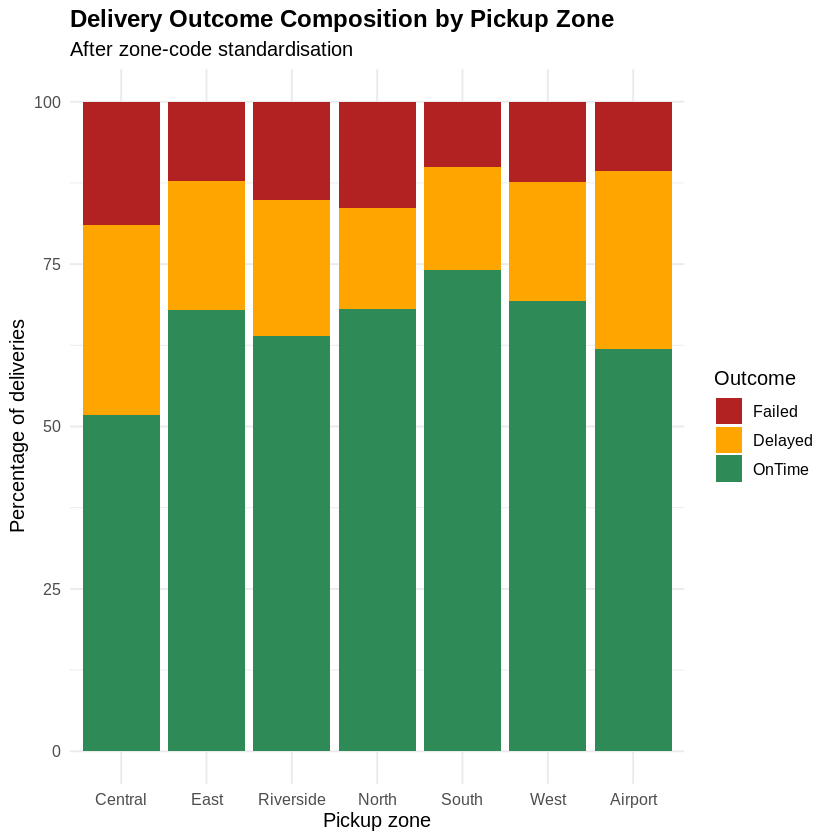

In [89]:
# 4.7 a)Plot 1: stacked bar chart of delivery outcomes by cleaned zone
# Problems 1 (cleaned) and 6 (zone-level performance variation)

p1 <- ggplot(zone_long,
             aes(x = reorder(pickup_zone_clean, -percentage),
                 y = percentage,
                 fill = factor(outcome,
                               levels = c("Failed", "Delayed", "OnTime")))) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("OnTime"  = "#2E8B57",
                               "Delayed" = "#FFA500",
                               "Failed"  = "#B22222")) +
  labs(title    = "Delivery Outcome Composition by Pickup Zone",
       subtitle = "After zone-code standardisation",
       x = "Pickup zone", y = "Percentage of deliveries",
       fill = "Outcome") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

print(p1)
ggsave("plot_zone_outcomes.png", p1, width = 9, height = 5, dpi = 150)

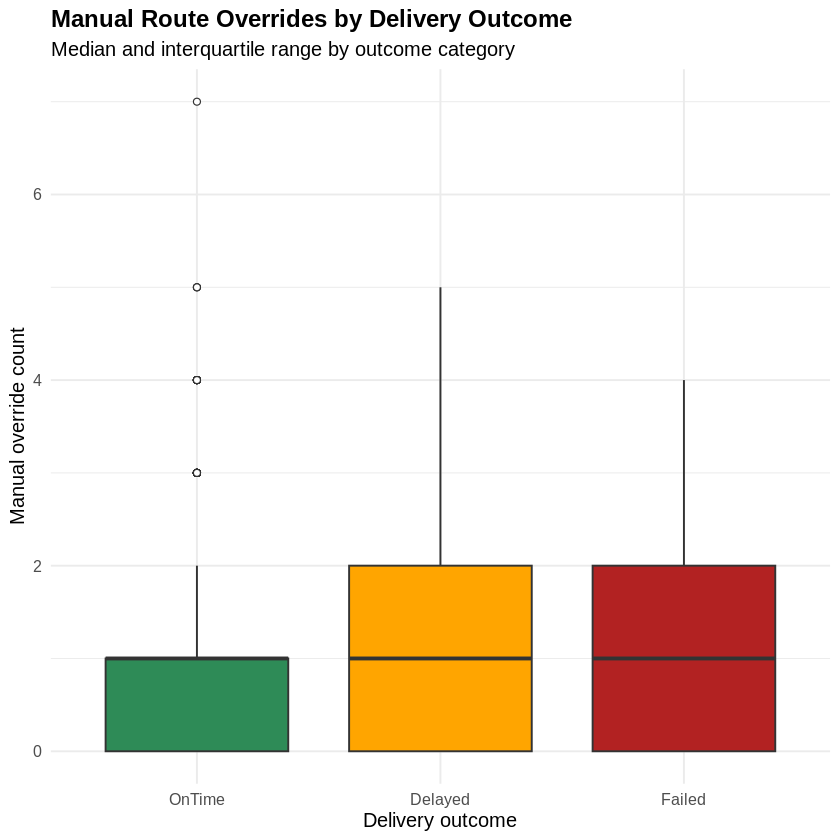

In [90]:
# 4.7 b)Plot 2: boxplot of override count by delivery outcome
# Problem 4 - visual test of the override-vs-outcome relationship

p2 <- ggplot(deliveries,
             aes(x = factor(delivery_status,
                            levels = c("OnTime", "Delayed", "Failed")),
                 y = manual_route_override_count,
                 fill = delivery_status)) +
  geom_boxplot(outlier.shape = 21, outlier.fill = "white") +
  scale_fill_manual(values = c("OnTime"  = "#2E8B57",
                               "Delayed" = "#FFA500",
                               "Failed"  = "#B22222")) +
  labs(title    = "Manual Route Overrides by Delivery Outcome",
       subtitle = "Median and interquartile range by outcome category",
       x = "Delivery outcome", y = "Manual override count") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.title      = element_text(face = "bold"))

print(p2)
ggsave("plot_overrides_boxplot.png", p2, width = 8, height = 5, dpi = 150)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


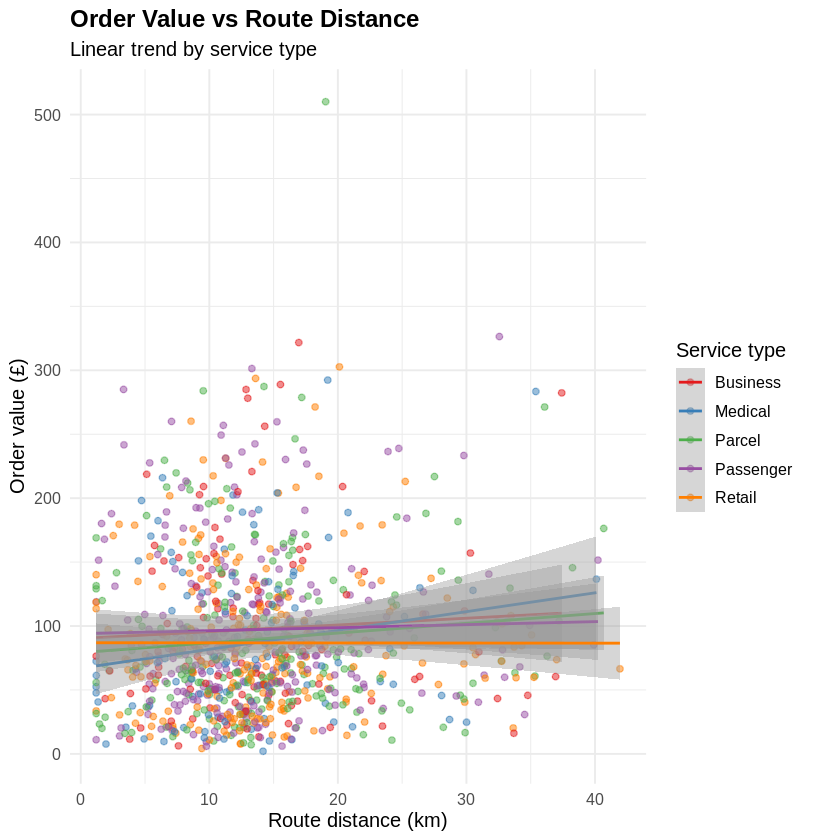

In [91]:
# 4.7 c)Plot 3: scatter plot of route distance vs order value with trend line
# Exploratory: reveals the pricing-distance relationship and outlier orders

plot_data <- orders %>%
  inner_join(deliveries %>% select(order_id, route_distance_km),
             by = "order_id") %>%
  filter(route_distance_km > 0, order_value > 0)

p3 <- ggplot(plot_data,
             aes(x = route_distance_km, y = order_value,
                 colour = service_type)) +
  geom_point(alpha = 0.5, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 0.8) +
  scale_colour_brewer(palette = "Set1") +
  labs(title    = "Order Value vs Route Distance",
       subtitle = "Linear trend by service type",
       x = "Route distance (km)", y = "Order value (£)",
       colour = "Service type") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

print(p3)
ggsave("plot_distance_revenue.png", p3, width = 9, height = 5, dpi = 150)

## Section Summary

This notebook addressed the Stage 1 problems through SQL within R:

- **P1** (zone fragmentation): surfaced in §4.4a aggregation, resolved in 4.6 a standardisation
- **P2** (timestamp impossibilities):  surfaced in 4.5 e, with all examples carrying 'OnTime' status
- **P3** (hidden complaints): quantified in 4.5 a (149 'OnTime' deliveries with complaints) and 4.5 d
- **P4** (route overrides): analysed in 4.5 c, visualised in 4.7 b
- **P6** (zone failure rates): quantified in 4.5 b (raw zones) and 4.6 b (cleaned zones), visualised in 4.7a

Notebook 02 (R Analytics) extends these descriptive findings with hypothesis testing.